In [5]:
import numpy as np
import pandas as pd
import datetime
from datetime import datetime, timedelta
# For importing universal scripts
import sys
import os
# Go up two levels from the subfolder
sys.path.append(os.path.abspath(".."))
from indicators_returns import final_df #Universal script for indicator set and actuals
import importlib
import indicators_returns
importlib.reload(indicators_returns)
from indicators_returns import final_df
import gc
from sklearn.metrics import (fbeta_score, accuracy_score, f1_score, 
                             confusion_matrix, balanced_accuracy_score, recall_score, matthews_corrcoef, precision_score)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBClassifier
import math
import pickle
import itertools

tags = pd.read_csv('../Indicator_Selection_Pipeline/Finalization/tags_cons.csv') 

def extract(ticker, returns, lb, cat_cols_all, windows=[]):
    
    df = final_df(ticker, returns, lb)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

# Start with must include columns (slope)

In [7]:
def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            print(f"  Threshold {thresh}: {metric_values}")
    
def optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, test_length, val_length, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh):
        
        # Create a Stratified K-Fold object
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Perform Random Search
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,  # Corrected from param_grid to param_distributions
            scoring=opt,
            cv=stratified_kfold,
            n_jobs=-1,
            n_iter=40,  # Adjust this based on how many random samples you want to try
            random_state=42  # Ensures reproducibility
        )

        random_search.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        verbose=False)
        best_model = random_search.best_estimator_
        # Predict probabilities
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        # Evaluate metrics for each threshold
        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                poscnt = sum(y_pred_valid == 1)
                negcnt = sum(y_pred_valid == 0)
                posrec = round(posprec * poscnt / postot, 2)
                negrec = round(negprec * negcnt / negtot, 2)
                metrics[t] = {
                    'TT_Len': len(df_indicators),
                    "PosTot": postot,  
                    "NegTot": negtot,  
                    "PosRec": posrec,
                    'PosPrec': posprec,  
                    "NegRec": negrec,
                    'NegPrec': negprec,  
                    'PosFb': round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                }
            else:
                metrics[t] = {'F1': 0, 'BalAcc': 0, 'PosAcc': 0, 'NegAcc': 0, 'PosCnt': 0, 'NegCnt': 0}

        del random_search
        gc.collect()

        return metrics, best_model

    # Deep --> change these for different model archs or add additional dicts and loop through each
    xgboost_hyperparameters = {
        'scale_pos_weight': [scale_pos_weight],
        'n_estimators': [300, 400, 500],
        'max_depth': [8, 10, 12], 
        'learning_rate': [0.01],
        'subsample': [0.75, .85],
        'colsample_bytree': [0.75, 0.85], 
        'gamma': [0.1, 0.2],
        'alpha': [0.1, 1], 
        'lambda': [1, 2, 5], 
        'min_child_weight': [5, 7],
        'early_stopping_rounds': [10]
    }
        
    X_test = df_indicators.iloc[:test_length].copy()
    y_test = df_predict.iloc[:test_length].copy()
    df_indicators = df_indicators.iloc[test_length:].copy()
    df_predict = df_predict.iloc[test_length:].copy()
    
    X_val = df_indicators.iloc[:val_length].copy()
    y_val = df_predict.iloc[:val_length].copy()
    X_train = df_indicators.iloc[val_length:].copy()
    y_train = df_predict.iloc[val_length:].copy()

    # Random split instead of sequential split
    #X_train, X_val, y_train, y_val = train_test_split(df_indicators, df_predict, test_size=0.3, random_state=42, shuffle=False)

    # Train and evaluate models
    xg_metrics, best_xg_model = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh)
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        return best_xg_model
    
def save(best_model, days, model, ticker):
    
    directory = f'../Leo_Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+'.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+'_'+' Returns')

# Velocity x Category Combo Groupings

In [38]:
raw_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist()
cat_slow = tags[(tags['Type'] == 'Raw') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
cat_moderate = tags[(tags['Type'] == 'Raw') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
cat_fast = tags[(tags['Type'] == 'Raw') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

# By category × velocity
duration_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
duration_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
duration_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

trend_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
trend_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
trend_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

trend_ratio_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
trend_ratio_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
trend_ratio_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

volatility_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
volatility_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
volatility_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

momentum_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
momentum_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
momentum_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

# If you want to smooth a hyper fast variable --> windows must be added to extract function and group_cols to work
raw_volatility_fast_25 = [f"{col}_EMA25" for col in volatility_fast]
raw_momentum_fast_25 = [f"{col}_EMA25" for col in momentum_fast]
trend_slow_25 = [f"{col}_EMA25" for col in trend_slow]
trend_ratio_slow_25 = [f"{col}_EMA25" for col in trend_ratio_slow]

# 1) Map your 15 groups to their feature‐lists
group_cols = {
    'duration_slow': duration_slow,
    'duration_moderate': duration_moderate,
    'duration_fast': duration_fast,
    'trend_slow': trend_slow,
    'trend_moderate': trend_moderate,
    'trend_fast': trend_fast,
    'trend_ratio_slow': trend_ratio_slow,
    'trend_ratio_moderate': trend_ratio_moderate,
    'trend_ratio_fast': trend_ratio_fast,
    'volatility_slow': volatility_slow,
    'volatility_moderate': volatility_moderate,
    'volatility_fast': volatility_fast,
    'momentum_slow': momentum_slow,
    'momentum_moderate': momentum_moderate,
    'momentum_fast': momentum_fast,
}

group_names = list(group_cols.keys())

# 2) Generate all 5‐combos, filtering out any with >2 from one category
valid_combos = []
for combo in itertools.combinations(group_names, 5):
    # extract the category portion (everything before the last "_")
    cats = [name.rsplit('_', 1)[0] for name in combo]
    # ensure no category appears more than twice
    if all(cats.count(cat) <= 2 for cat in set(cats)):
        valid_combos.append(combo)

# 3) (Optional) Build a mapping from combo → flattened feature list
combos_features = {
    combo: [feat for grp in combo for feat in group_cols[grp]]
    for combo in valid_combos
}

print(len(combos_features))

2673


# Training Loop

In [26]:
tickers = ['QQQ']#, 'NVDA', "AAPL", "MSFT", "TSLA", "AMZN", "AVGO", "META", "GOOGL", "COST", "NFLX"]
thresh = [.5, .55] 
returns = [5]#, 10, 20, 30]# n_days predicted in target outcome
smoothing_windows = [10, 25] # smoothing windows used in extract function --> ignore
lookback_periods = [12, 10, 8] # how many years back to pull historic data
test_length = 100 # size of the test set which isn't using in training or validation
val_length = 400 # size of validation set which is withheld from training but used to measure performance

results = []
name_to_combo = { "_".join(c): c for c in valid_combos } # also possible combinations of feature lists to test
cat_cols_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist() # cols smoothing windows will be applied to in extract function
for ticker in tickers:

    for r in returns:
            
        for combo in valid_combos:
            for lookback_period in lookback_periods:

                df = extract(ticker, returns, lookback_period, cat_cols_all, smoothing_windows)
            
                combo_name = "+".join(combo)
                cols = combos_features[combo]
                
                #df = extract(ticker, returns, lb, cat_cols_all, windows=[10, 25])
                df_ph = df.copy()
                df_ph = df_ph.iloc[r:].copy() # clip records without a known outcome
                return_col = f"Return_{r}"
                model_key = f"QQQ_{r}"
                counts = df_ph[return_col].value_counts()
                neg = counts.get(0, 0)
                pos = counts.get(1, 1)  # prevent division by zero
                scale_pos_weight = neg / pos # used to make sure the model penalizes poor performance on both classes equally

                # Choose evaluation metric
                opt = 'matthews_corrcoef' # optimization metric, could be f1, accuracy, balanced accuracy, etc

                # Combine features with return column, drop missing
                used_cols = cols + [return_col]
                df_model = df_ph[used_cols].dropna()
                
                df_indicators = df_model[cols]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                
                print(f"Results for {combo_name} | {ticker}_{r} lb: {lookback_period} ")
                xg_metrics, best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, test_length, val_length, return_metrics=True)
                metrics = list(xg_metrics.values())[0]
                #save(best_xg_model, r, combo_name, ticker)
                # build one flat record
                row = {'name': combo_name, 'ticker': ticker, 'horizon': r, **metrics}
                results.append(row)
                print('---------------------------')

Results for volatility_slow+volatility_moderate | QQQ_5 lb: 12 
  Threshold 0.5: {'TT_Len': 2645, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.76, 'PosPrec': 0.6, 'NegRec': 0.27, 'NegPrec': 0.44, 'PosFb': 0.645, 'NegFb': 0.364}
  Threshold 0.55: {'TT_Len': 2645, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.34, 'PosPrec': 0.67, 'NegRec': 0.02, 'NegPrec': 0.5, 'PosFb': 0.506, 'NegFb': 0.056}
---------------------------
Results for volatility_slow+volatility_moderate | QQQ_5 lb: 10 
  Threshold 0.5: {'TT_Len': 2143, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.8, 'PosPrec': 0.59, 'NegRec': 0.2, 'NegPrec': 0.4, 'PosFb': 0.647, 'NegFb': 0.3}
  Threshold 0.55: {'F1': 0, 'BalAcc': 0, 'PosAcc': 0, 'NegAcc': 0, 'PosCnt': 0, 'NegCnt': 0}
---------------------------
Results for volatility_slow+volatility_moderate | QQQ_5 lb: 8 


/var/folders/k0/mlnk5_mx6ns64dfxsknt0p3m0000gn/T/ipykernel_38398/3612255984.py:56: RuntimeWarning: invalid value encountered in scalar divide
  'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),


  Threshold 0.5: {'TT_Len': 1655, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.74, 'PosPrec': 0.73, 'NegRec': 0.6, 'NegPrec': 0.62, 'PosFb': 0.733, 'NegFb': 0.613}
  Threshold 0.55: {'TT_Len': 1655, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.03, 'PosPrec': 1.0, 'NegRec': 0.0, 'NegPrec': 0.0, 'PosFb': 0.085, 'NegFb': nan}
---------------------------
Results for volatility_slow+volatility_fast | QQQ_5 lb: 12 


/var/folders/k0/mlnk5_mx6ns64dfxsknt0p3m0000gn/T/ipykernel_38398/3612255984.py:56: RuntimeWarning: invalid value encountered in scalar divide
  'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),


  Threshold 0.5: {'TT_Len': 2645, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.75, 'PosPrec': 0.64, 'NegRec': 0.39, 'NegPrec': 0.52, 'PosFb': 0.673, 'NegFb': 0.468}
  Threshold 0.55: {'TT_Len': 2645, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.24, 'PosPrec': 0.61, 'NegRec': 0.0, 'NegPrec': 0.0, 'PosFb': 0.403, 'NegFb': nan}
---------------------------
Results for volatility_slow+volatility_fast | QQQ_5 lb: 10 


KeyboardInterrupt: 

In [15]:
result_df = pd.DataFrame(results)
result_df
result_df.to_csv('test.csv')

In [43]:
trend_ratio_slow

['100_SMA_200',
 '100_EMA_200',
 '50_SMA_100',
 '50_EMA_100',
 '25_EMA_50',
 '50_SMA_200',
 '50_EMA_200']

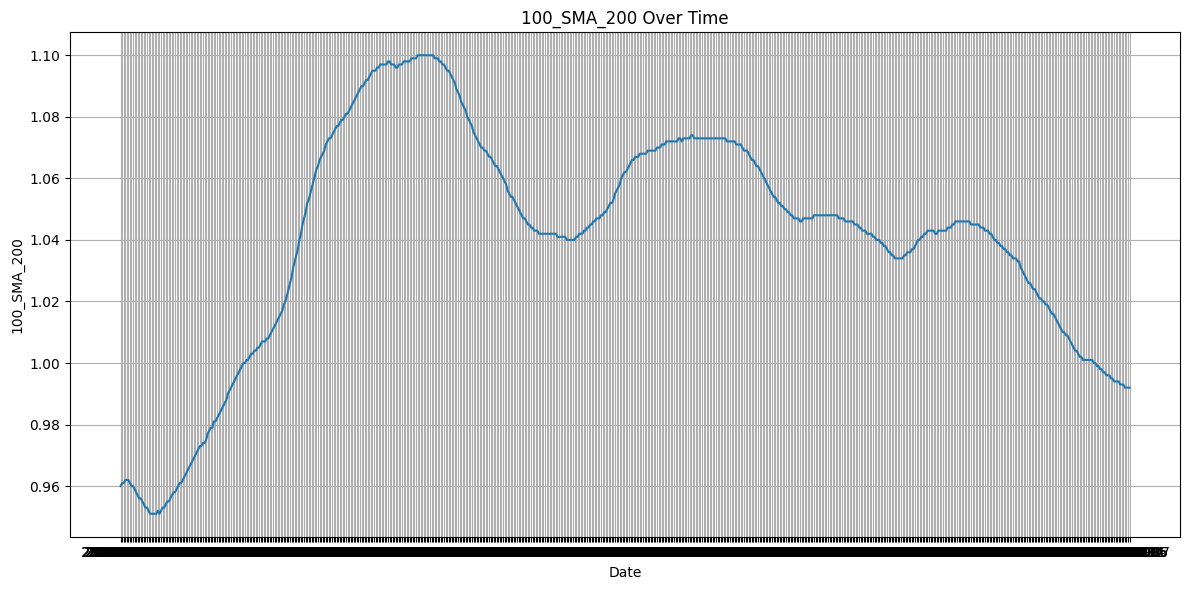

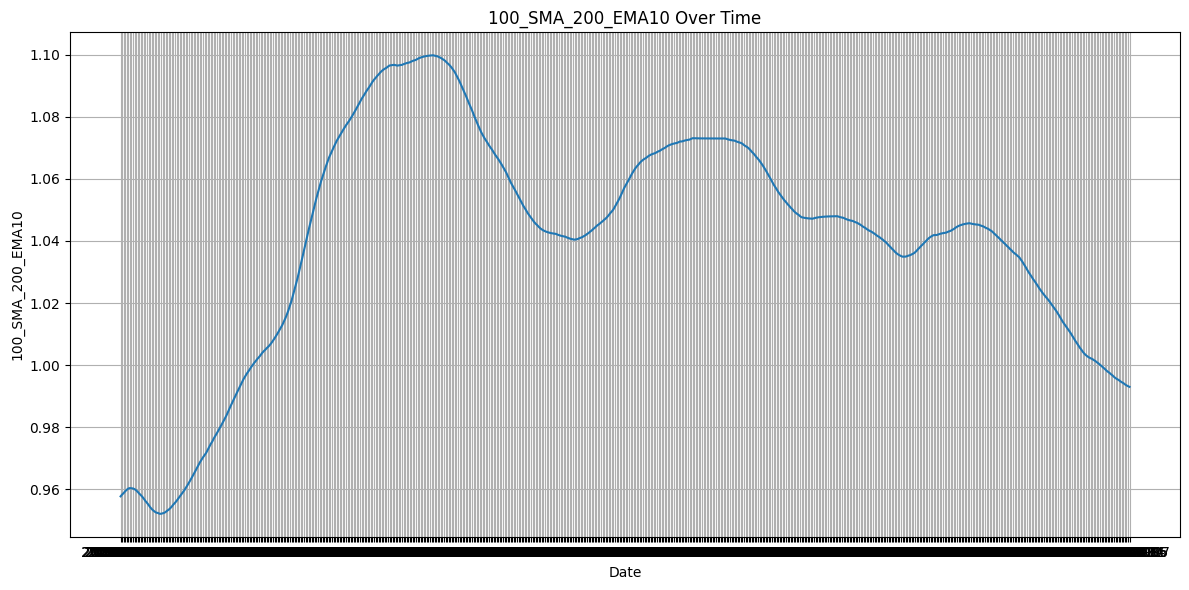

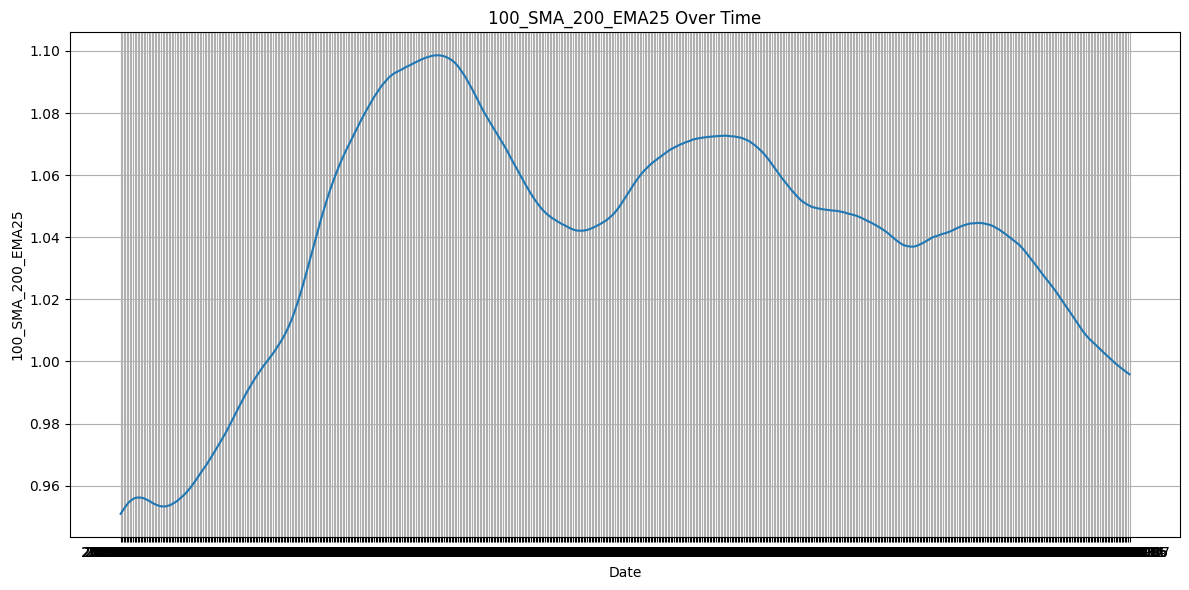

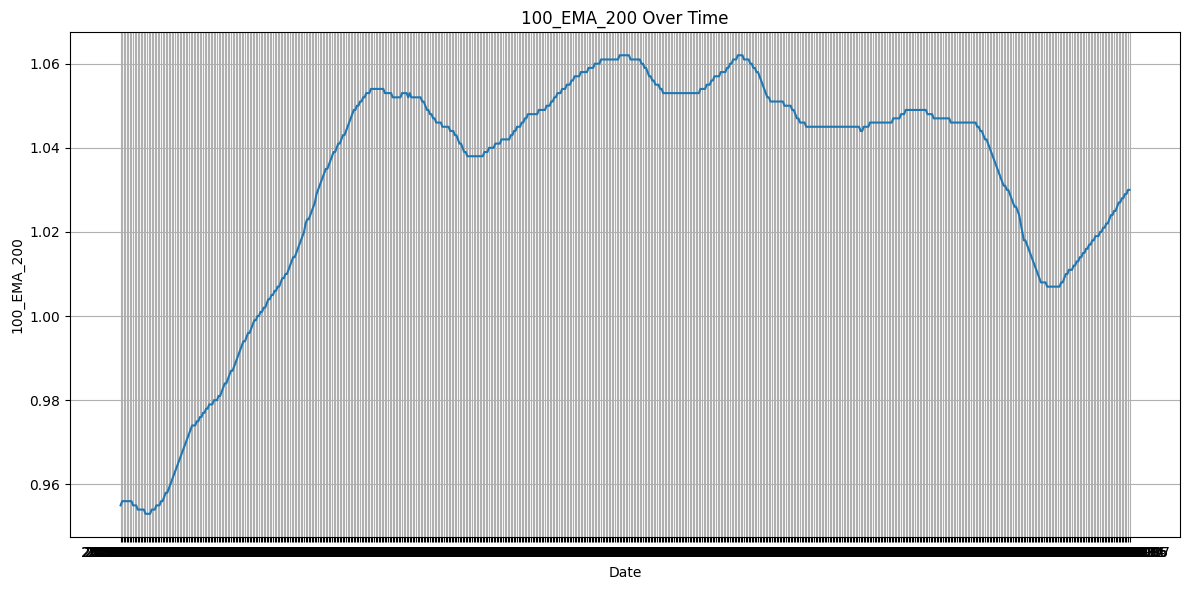

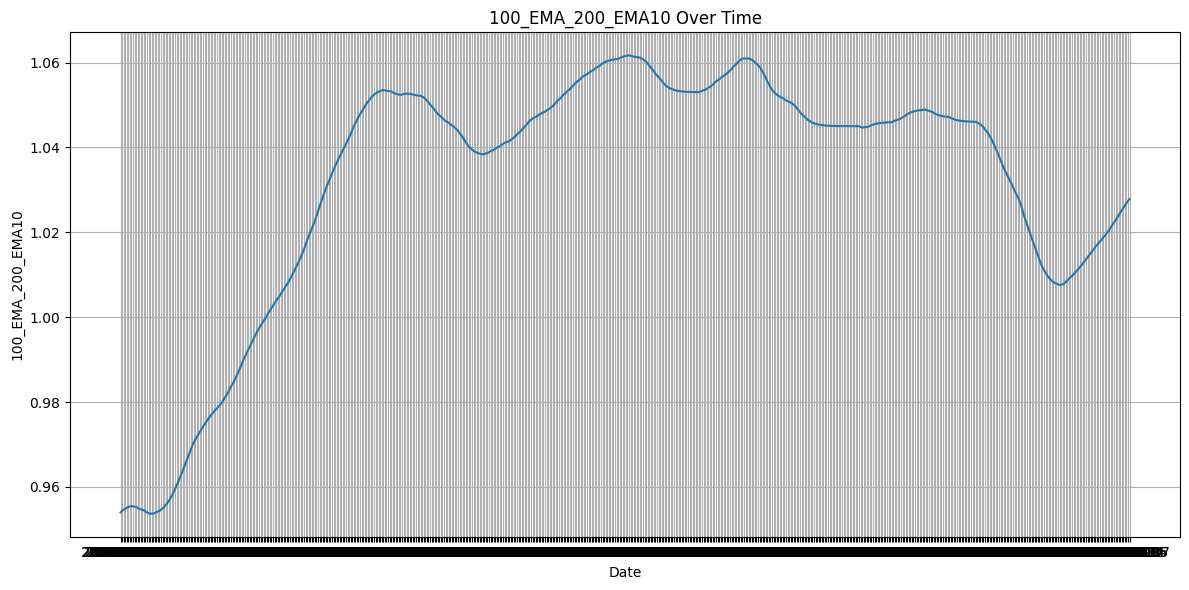

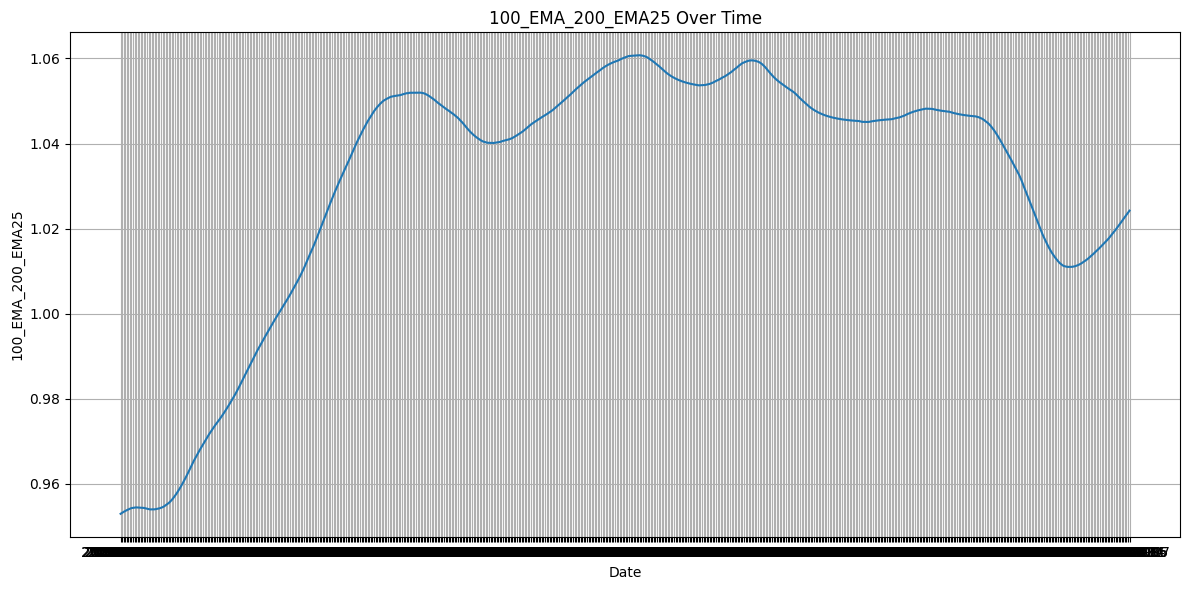

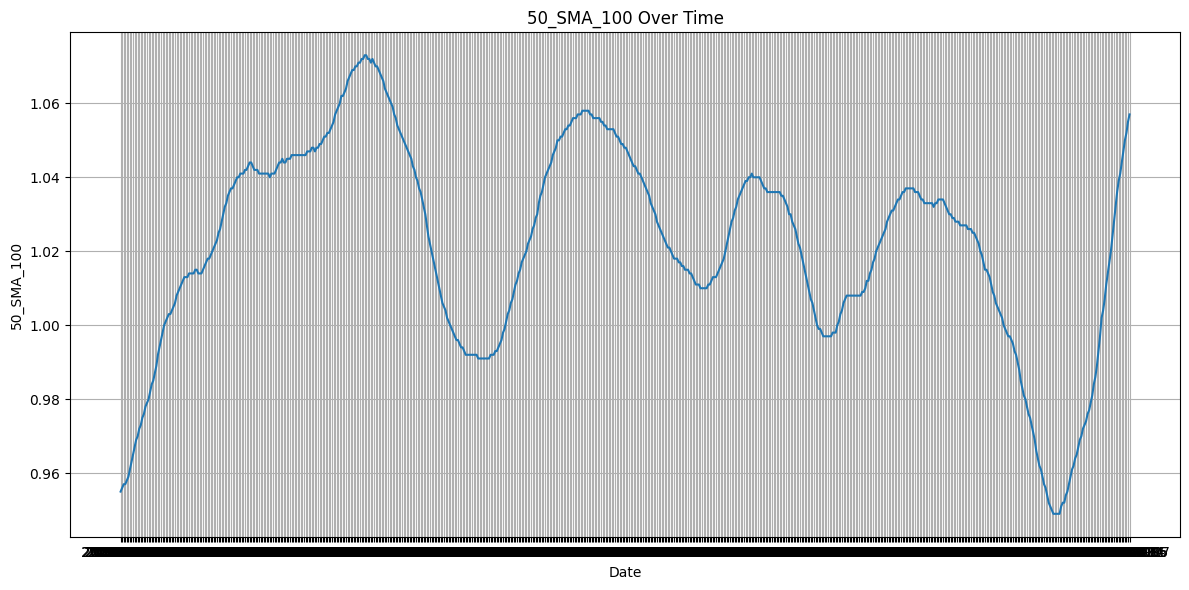

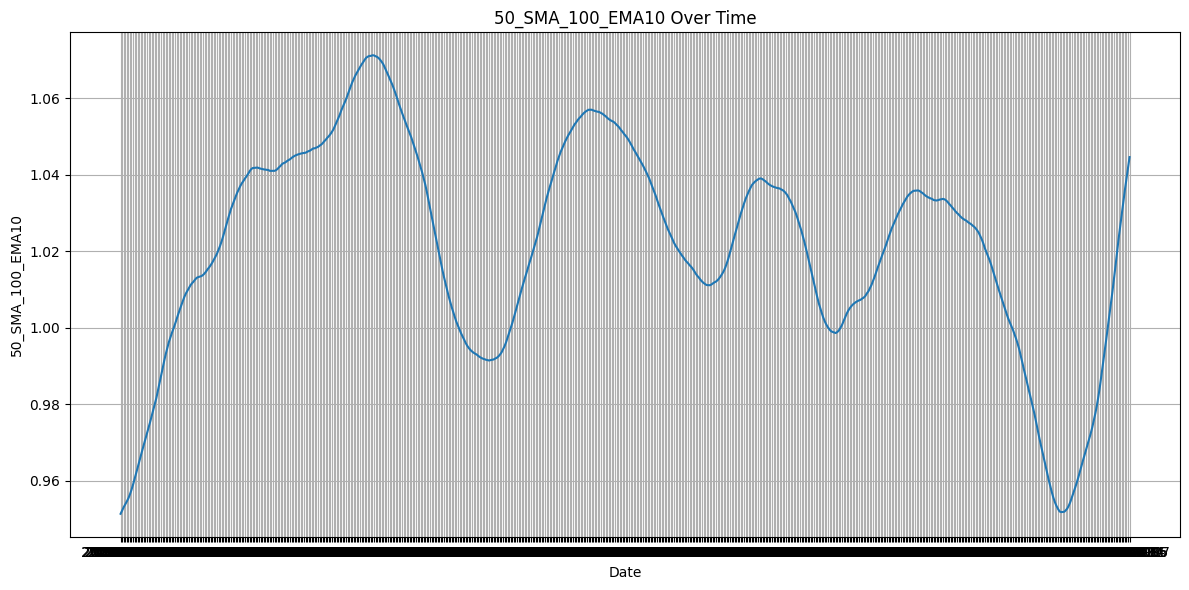

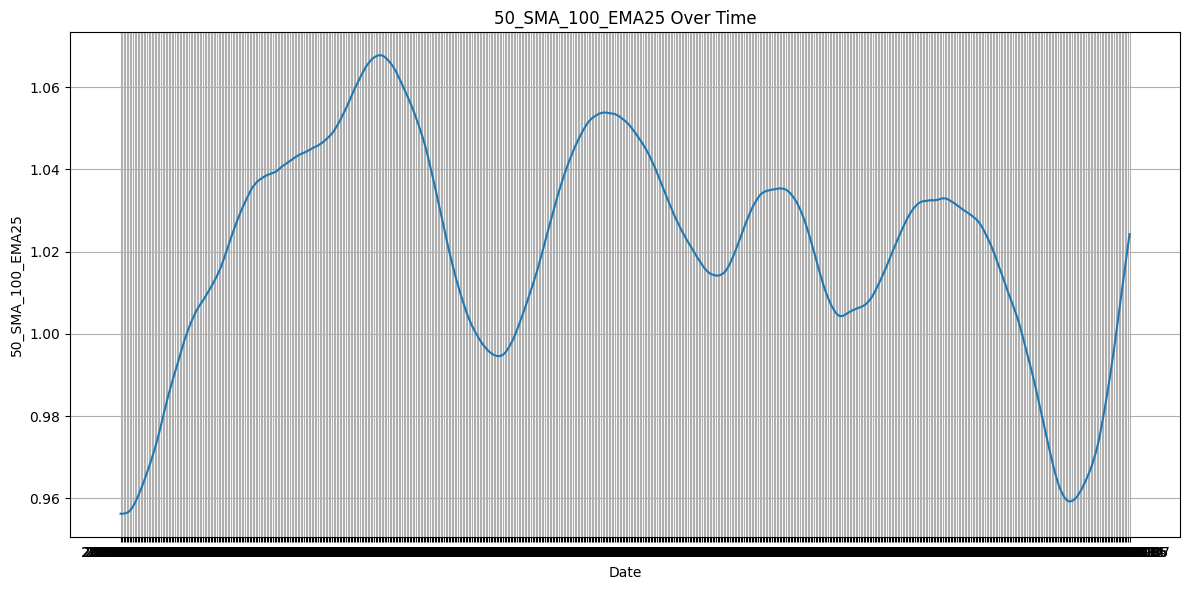

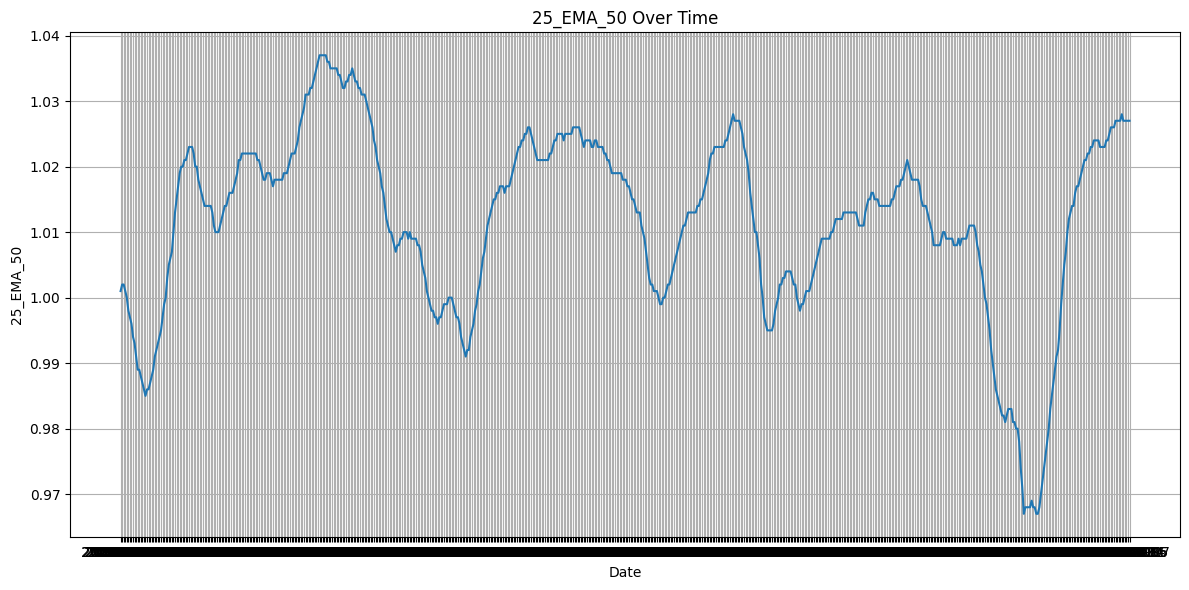

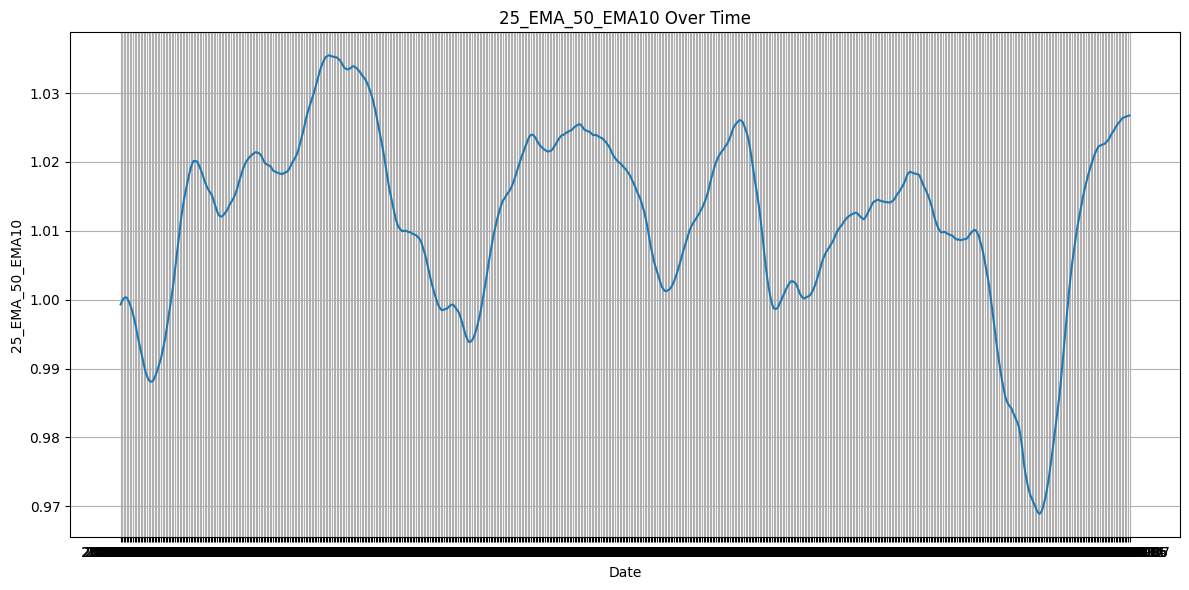

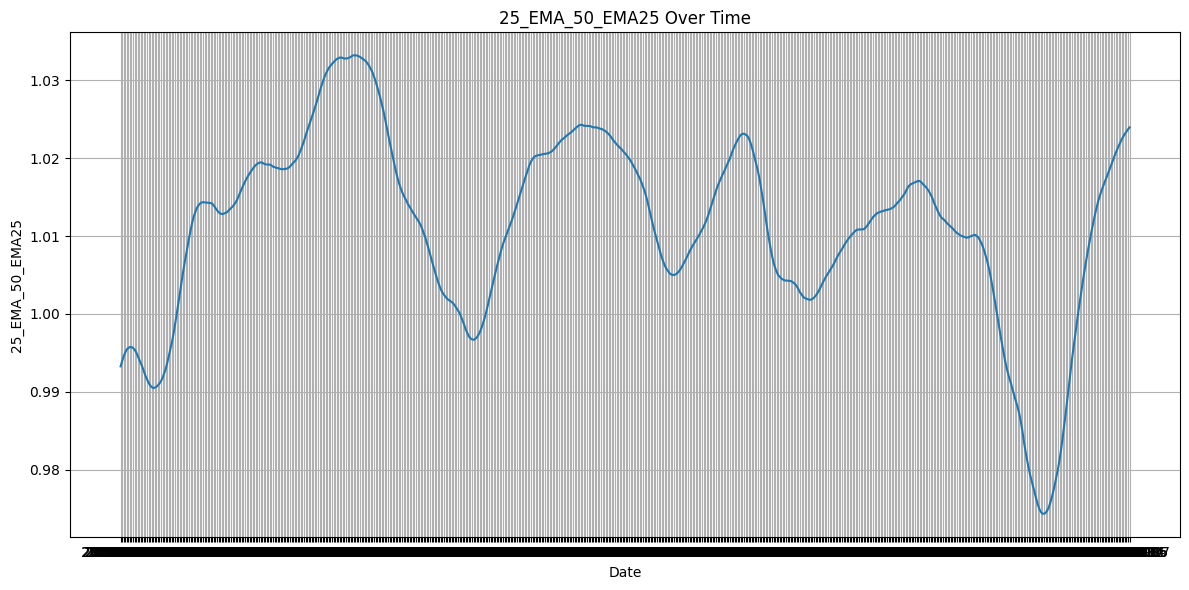

In [44]:
import matplotlib.pyplot as plt
#df = extract('QQQ', returns, lb, raw_all, windows=[10,25])

cols = trend_slow + trend_slow_25 + trend_ratio_slow + trend_ratio_slow_25
cols = ['100_SMA_200', '100_SMA_200_EMA10', '100_SMA_200_EMA25', 
        '100_EMA_200', '100_EMA_200_EMA10', '100_EMA_200_EMA25',
        '50_SMA_100', '50_SMA_100_EMA10', '50_SMA_100_EMA25', 
        '25_EMA_50', '25_EMA_50_EMA10', '25_EMA_50_EMA25']

for col in cols:
    try:
        plt.figure(figsize=(12, 6))
        plt.plot(df['Date'].iloc[:650].sort_index(ascending=True), df[col].iloc[:650].sort_index(ascending=True))
        plt.xlabel('Date')
        plt.ylabel(f'{col}')
        plt.title(f'{col} Over Time')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except KeyError:
        continue